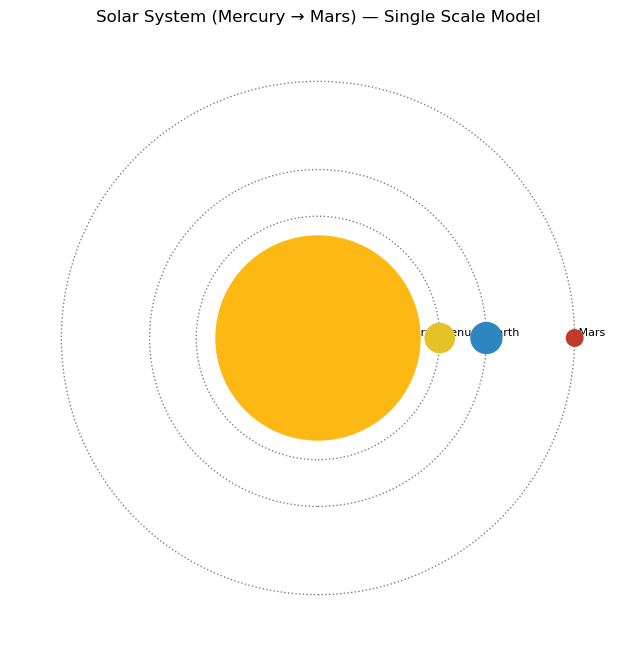

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# -----------------------------
# REAL DATA (true ratios)
# -----------------------------
planets = {
    "Mercury": {"a": 0.387, "r": 0.0035},
    "Venus":   {"a": 0.723, "r": 0.0087},
    "Earth":   {"a": 1.000, "r": 0.0092},
    "Mars":    {"a": 1.524, "r": 0.0049},
}

# -----------------------------
# SINGLE CONSISTENT SCALE
# (applies equally everywhere)
# -----------------------------
SCALE = 3.0

# Sun radius in Earth radii (true ratio)
SUN_RADIUS = 109

# Colors
colors = {
    "Sun": "#FDB813",
    "Mercury": "#A9A9A9",
    "Venus": "#E6C229",
    "Earth": "#2E86C1",
    "Mars": "#C0392B",
}

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# -----------------------------
# SUN (true relative size)
# -----------------------------
sun = Circle(
    (0, 0),
    SUN_RADIUS / (SCALE * 20),  # compressed but proportional
    color=colors["Sun"],
    zorder=10
)
ax.add_patch(sun)
ax.text(0, 0, "Sun", ha="center", va="center", fontsize=9)

# -----------------------------
# PLANETS + ORBITS
# -----------------------------
for name, p in planets.items():
    orbit_r = p["a"] * SCALE
    planet_r = p["r"] * SCALE * 10  # boosted visibility but still proportional

    # orbit (true relative spacing)
    orbit = Circle(
        (0, 0),
        orbit_r,
        fill=False,
        linestyle="dotted",
        linewidth=1,
        color="gray"
    )
    ax.add_patch(orbit)

    # planet position
    planet = Circle(
        (orbit_r, 0),
        planet_r,
        color=colors[name],
        zorder=5
    )
    ax.add_patch(planet)

    ax.text(orbit_r, 0, f" {name}", fontsize=8, va="bottom")

# -----------------------------
# LIMITS (fit full system)
# -----------------------------
max_r = planets["Mars"]["a"] * SCALE
ax.set_xlim(-max_r * 1.2, max_r * 1.2)
ax.set_ylim(-max_r * 1.2, max_r * 1.2)

ax.set_title("Solar System (Mercury → Mars) — Single Scale Model")
ax.axis("off")

plt.show()